# Voltage Oscillations in the Barnacle Giant Muscle Fiber

## Libraries

In [3]:
import numpy as np 
import matplotlib.pyplot as plt


## Barnacle Model

In [ ]:
class BarnacleNeuron():
    def __init__(self,I:float, Il: float,
                       gl: int, gk: int, gca: int,
                       Vl: int, Vk: int, Vca: int,
                       V1: float, V2: float, V3: float, V4: float,V_o: float,
                       lambda_M: float, lambda_N: float,
                       Ca_i: float, Ca_o:float,C: int):
        # currents 
        self.I = I # input current 
        self.Il = Il # leak current 
        #self.Ik = Ik # K+ current 
        #self.Ica = Ica # Ca++ current

        # maximum or instaneous conductances 
        self.gl = gl # leak conductnace 
        self.gk = gk # K+ conductance 
        self.gca = gca # Ca++ conductance 

        # potentials  
        self.V_o = V_o
        self.Vl = Vl # leak potential  
        self.Vk = Vk # Ca++ potential 
        self.Vca = Vca # K+ potential  

        self.V1 = V1 # potential where M_inf = 0.5 mV
        self.V2 = V2 # recriprocal of slope of voltage dependency of M_inf 
        self.V3 = V3 # potential where N_inf = 0.5 mV
        self.V4 = V4 # recriprocal of slope of voltage dependency of N_inf 


        # constants 
        self.lambda_M = lambda_M # maximum rate constant for Ca++ channel opening (s-1)
        self.lambda_N = lambda_N # maximum rate constant for K+ channel opening (s-1)

        self.Ca_i = Ca_i # internal Ca++ concentration 
        self.Ca_o = Ca_o # external Ca++ concentration 
        self.F = 96485 # Faraday constant 
        self.C = C # membrane capacitence 
    
    # fraciton of open M channels at steady state
    def M_inf(self,V_idx):
        return .5 * (1 + np.tanh((V_idx - self.V1)/self.V2))

    # fraction of open N channels at steady state 
    def N_inf(self,V_idx):
        return .5 * (1 + np.tanh((V_idx - self.V3)/self.V4))

   # rate constant for opening of Ca+ channel 
    def compute_lambda_M(self,V_idx):
        return self.lambda_M * np.cosh((V_idx - self.V1) / (2 * self.V2))

    # rate constant for opening of K+ channel 
    def compute_lambda_N(self,V_idx):
        return self.lambda_N * np.cosh((V_idx - self.V3) / (2 * self.V4))

    def compute_I(self,V):
        leak_term = self.gl * self.Vl 
        ca_term = self.gca * self.M * (V-self.Vca)
        k_term = self.gka *self.N * (V - self.Vka)
        return self.C * V + leak_term + ca_term + k_term 

    def compute_M(self,V_idx):
        return self.lambda_M(V_idx)*(self.M_inf(V_idx)-self.M)
    
    def compute_N(self,V_idx):
        return self.lambda_N(V_idx)*(self.N_inf(V_idx)-self.N)

    
    def compute_step(self,idx): 
        if (self.i == "Ca"):
            gi = self.gca
            mu = self.M[idx]
            Vi = self.Vca

        elif (self.i=="K"): 
            gi = self.gk
            mu = self.N[idx]
            Vi = self.Vk

        # voltage 
        dVdt = (self.I - self.gl * (self.V[idx] - self.Vl) - gi * mu * (self.V[idx] - Vi))/ self.C  
        self.V[idx+1] = self.V[idx] + self.dt * dVdt

        # M 
        if (self.i == "Ca"):
            dMdt = self.compute_lambda_M(self.V[idx]) * (self.M_inf(self.V[idx]) - self.M[idx])
            self.M[idx+1] =  self.M[idx] + self.dt * dMdt

        # N 
        elif (self.i == "K"):
            DNdt = self.compute_lambda_N(self.V[idx]) * (self.N_inf(self.V[idx]) - self.N[idx])
            self.N[idx+1] =  self.N[idx] + self.dt * DNdt 


   # def nullcline(self,):

    def apply_eulers(self,dt,T,i):
       # self.reset()
        self.T = T
        self.dt = dt
        self.i = i

        self.n_steps = int(self.T/self.dt )


        self.V = np.zeros(self.n_steps) 
        self.V[0] = self.V_o

        self.M = np.zeros(self.n_steps) 
        self.M[0] = self.M_inf(self.Vl)

        self.N = np.zeros(self.n_steps) 
        self.N[0] = self.N_inf(self.Vl)


        for idx in range(self.n_steps-1):
            self.compute_step(idx)
    
    def plot_V(self,label):        
        t = np.linspace(0,self.T,self.n_steps)
        plt.plot(t,self.V,label=label)
 


# Simulations 

In [ ]:
# defining parameters
I_vals = [25, 100, 400] # I values plotted on figure 2b 

gca = 0 
gk = 8 
gl = 3 
Vk = -70 
Vl = -50 
lambda_N = 1/15
lambda_M = 1/15

C = 20 

V3 = -1.0 
V4 = 14.5

T = 250 # 250 ms 
dt = .001 # .001 second  

N_sim0 = BarnacleNeuron(I=I_vals[0],gl=gl, gk=gk, gca=gca, Vl=Vl, 
                        Vca=0, V1=-1, V2=1,lambda_M=0, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)
N_sim1 = BarnacleNeuron(I=I_vals[1],gl=gl, gk=gk, gca=gca, Vl=Vl, 
                        Vca=0, V1=-1, V2=1,lambda_M=0, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)
N_sim2 = BarnacleNeuron(I=I_vals[2],gl=gl, gk=gk, gca=gca, Vl=Vl, 
                        Vca=0, V1=-1, V2=1,lambda_M=0, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)
N_sim3 = BarnacleNeuron(I=I_vals[3],gl=gl, gk=gk, gca=gca, Vl=Vl, 
                        Vca=0, V1=-1, V2=1,lambda_M=0, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)

 
 
N_sim1.apply_eulers(dt=dt,T=T,i="K")
N_sim2.apply_eulers(dt=dt,T=T,i="K")
N_sim3.apply_eulers(dt=dt,T=T,i="K")
 

## Figure 2B

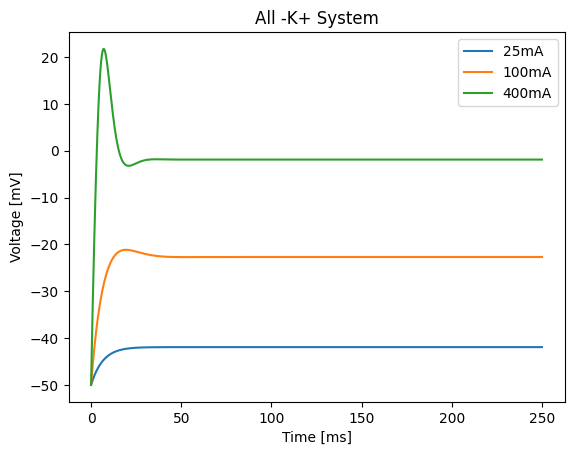

In [ ]:
N_sim1.plot_V("25mA")
N_sim2.plot_V("100mA")
N_sim3.plot_V("400mA")
plt.xlabel("Time [ms]")
plt.ylabel("Voltage [mV]")
plt.title("All -K+ System")
plt.legend()

## Figure 5A

In [ ]:
I_vals = [0,25, 100, 400] # I values plotted on figure 2b 


## Figure 6

## Figure 7